In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/dataset/Traffic_Sign-20260509T152655Z-3-001.zip'
extract_path = '/content/dataset/'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)
print("Done")

Done


In [5]:
os.makedirs('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures', exist_ok=True)
print("Done")

Done


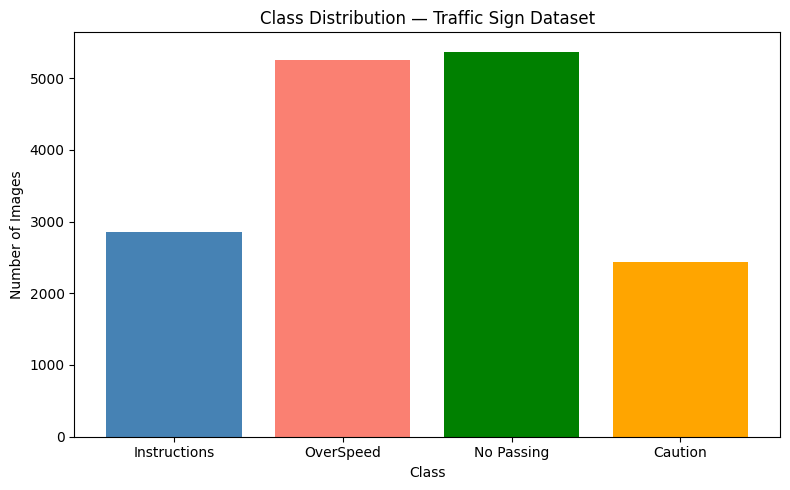

Class Distribution:
  Instructions: 2848 images
  OverSpeed: 5249 images
  No Passing: 5369 images
  Caution: 2429 images
  Total: 15895 images


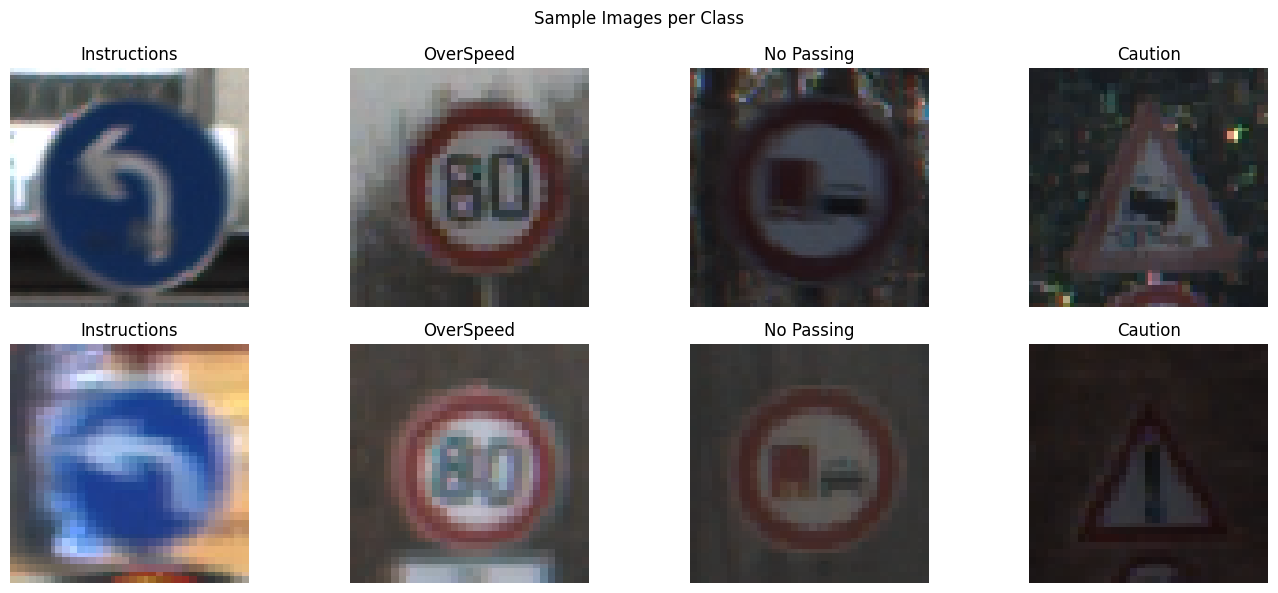

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os

dataset_path = '/content/dataset/Traffic_Sign'
train_path = os.path.join(dataset_path, 'Train')
classes = os.listdir(train_path)

# ── Class Distribution ──────────────────────────────────────────
class_counts = {}
for cls in classes:
    cls_path = os.path.join(train_path, cls)
    class_counts[cls] = len(os.listdir(cls_path))

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['steelblue', 'salmon', 'green', 'orange'])
plt.title('Class Distribution — Traffic Sign Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/class_dist.png', dpi=150)
plt.show()

print("Class Distribution:")
total = 0
for cls, count in class_counts.items():
    print(f"  {cls}: {count} images")
    total += count
print(f"  Total: {total} images")

# ── Sample Images ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_path, cls)
    images = os.listdir(cls_path)
    for j in range(2):
        img_path = os.path.join(cls_path, images[j])
        img = load_img(img_path, target_size=(64, 64))
        axes[j, i].imshow(img)
        axes[j, i].set_title(cls)
        axes[j, i].axis('off')

plt.suptitle('Sample Images per Class')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/sample_images.png', dpi=150)
plt.show()

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# ── Data Generators with Augmentation for Train ─────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print(f"\nClass indices: {train_generator.class_indices}")
print(f"Train batches: {len(train_generator)}")
print(f"Val batches: {len(val_generator)}")

Found 12719 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.

Class indices: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}
Train batches: 398
Val batches: 100


In [8]:
from PIL import Image
import os

train_path = '/content/dataset/Traffic_Sign/Train'
corrupt = []

for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception:
            corrupt.append(img_path)
            os.remove(img_path)

print(f"Removed {len(corrupt)} corrupt images")
for p in corrupt:
    print(p)

Removed 28 corrupt images
/content/dataset/Traffic_Sign/Train/Instructions/00035_00003_00001.png
/content/dataset/Traffic_Sign/Train/Instructions/00035_00019_00013.png
/content/dataset/Traffic_Sign/Train/Instructions/00028_00007_00009.png
/content/dataset/Traffic_Sign/Train/Instructions/00033_00015_00004.png
/content/dataset/Traffic_Sign/Train/Instructions/00028_00017_00025.png
/content/dataset/Traffic_Sign/Train/Instructions/00028_00013_00012.png
/content/dataset/Traffic_Sign/Train/Instructions/00028_00001_00009.png
/content/dataset/Traffic_Sign/Train/OverSpeed/00004_00058_00025.png
/content/dataset/Traffic_Sign/Train/OverSpeed/00005_00043_00008.png
/content/dataset/Traffic_Sign/Train/OverSpeed/00004_00005_00020.png
/content/dataset/Traffic_Sign/Train/OverSpeed/00005_00009_00027.png
/content/dataset/Traffic_Sign/Train/OverSpeed/00005_00035_00027.png
/content/dataset/Traffic_Sign/Train/OverSpeed/00005_00058_00027.png
/content/dataset/Traffic_Sign/Train/OverSpeed/00004_00057_00006.png
/

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=8,
    zoom_range=0.10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time

# ── Baseline CNN ────────────────────────────────────────────────
baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
], name='Baseline_CNN')

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# ── Train ───────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nTraining Baseline CNN...")
start = time.time()
history_baseline = baseline_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)
baseline_time = time.time() - start
print(f"\nBaseline training time: {baseline_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,564 (5.01 MB)

 Trainable params: 1,314,564 (5.01 MB)

 Non-trainable params: 0 (0.00 B)


Training Baseline CNN...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9208 - loss: 0.2165 - val_accuracy: 0.8146 - val_loss: 2.2936
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9883 - loss: 0.0403 - val_accuracy: 0.8102 - val_loss: 3.5716
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9945 - loss: 0.0185 - val_accuracy: 0.7919 - val_loss: 4.3092
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9951 - loss: 0.0193 - val_accuracy: 0.8197 - val_loss: 4.7554

Baseline training time: 131.45s


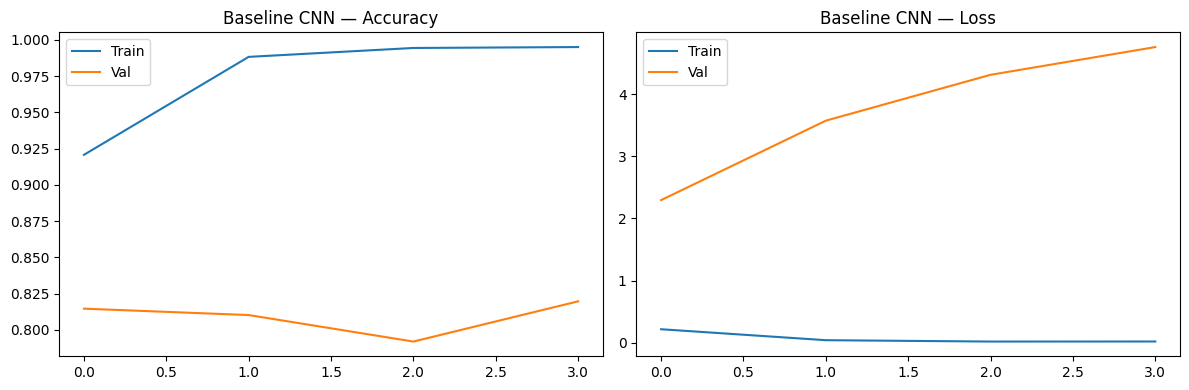

Evaluating Baseline CNN...
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step

Val Accuracy: 0.8146
              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       1.00      0.06      0.11       568
  No Passing       0.99      0.96      0.98      1072
   OverSpeed       0.96      0.99      0.97      1048

    accuracy                           0.81      3172
   macro avg       0.86      0.75      0.68      3172
weighted avg       0.90      0.81      0.77      3172



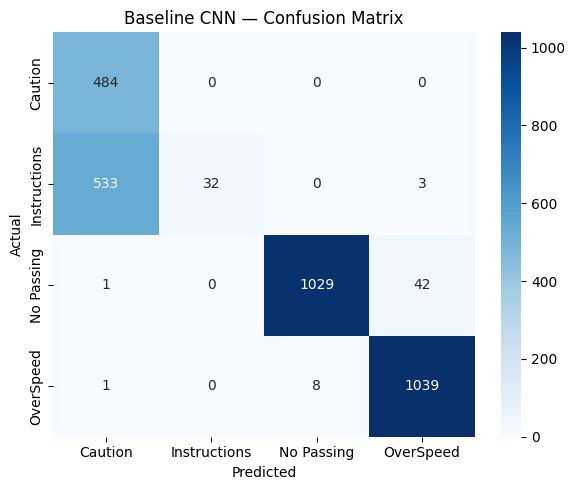

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ── Plot Training Curves ─────────────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train')
plt.plot(history_baseline.history['val_accuracy'], label='Val')
plt.title('Baseline CNN — Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train')
plt.plot(history_baseline.history['val_loss'], label='Val')
plt.title('Baseline CNN — Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_curves.png', dpi=150)
plt.show()

# ── Evaluate ─────────────────────────────────────────────────────
print("Evaluating Baseline CNN...")
val_generator.reset()
y_pred = baseline_model.predict(val_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

print(f"\nVal Accuracy: {np.mean(y_pred_classes == y_true):.4f}")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline CNN — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_cm.png', dpi=150)
plt.show()

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step

Val Accuracy: 0.8146
              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       1.00      0.06      0.11       568
  No Passing       0.99      0.96      0.98      1072
   OverSpeed       0.96      0.99      0.97      1048

    accuracy                           0.81      3172
   macro avg       0.86      0.75      0.68      3172
weighted avg       0.90      0.81      0.77      3172



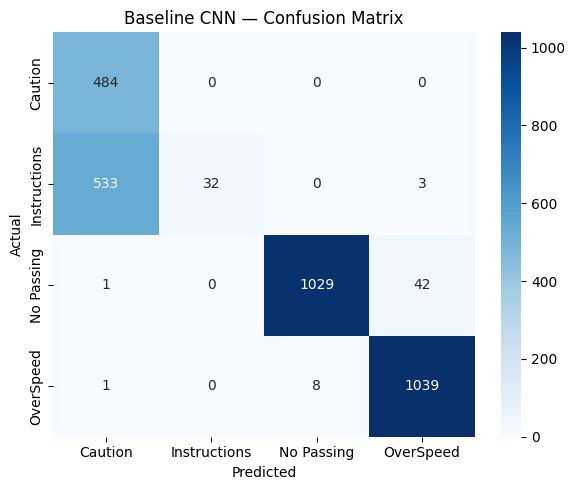

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Fresh val generator without augmentation
eval_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

eval_generator = eval_datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False  # critical for matching predictions to labels
)

# Evaluate
eval_generator.reset()
y_pred = baseline_model.predict(eval_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = eval_generator.classes
class_names = list(eval_generator.class_indices.keys())

print(f"\nVal Accuracy: {np.mean(y_pred_classes == y_true):.4f}")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline CNN — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/baseline_cm.png', dpi=150)
plt.show()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import tensorflow.keras.backend as K

K.clear_session()

deeper_model = Sequential([
    # Conv Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv Block 5
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    # Conv Block 6
    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
], name='Deeper_CNN')

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

# ── Train ───────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping
import time

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nTraining Deeper CNN...")
start = time.time()
history_deeper = deeper_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)
deeper_time = time.time() - start
print(f"\nDeeper CNN training time: {deeper_time:.2f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,89

 Total params: 6,531,204 (24.91 MB)

 Trainable params: 6,528,708 (24.91 MB)

 Non-trainable params: 2,496 (9.75 KB)


Training Deeper CNN...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 55s 106ms/step - accuracy: 0.7574 - loss: 0.6485 - val_accuracy: 0.5801 - val_loss: 1.7983
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.9761 - loss: 0.0962 - val_accuracy: 0.6608 - val_loss: 4.2924
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9892 - loss: 0.0408 - val_accuracy: 0.7762 - val_loss: 9.4478
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9942 - loss: 0.0251 - val_accuracy: 0.7702 - val_loss: 7.2045

Deeper CNN training time: 150.28s


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step

Deeper CNN Val Accuracy: 0.5801
              precision    recall  f1-score   support

     Caution       0.40      0.58      0.47       484
Instructions       0.96      0.04      0.08       568
  No Passing       1.00      0.46      0.63      1072
   OverSpeed       0.53      1.00      0.70      1048

    accuracy                           0.58      3172
   macro avg       0.72      0.52      0.47      3172
weighted avg       0.75      0.58      0.53      3172



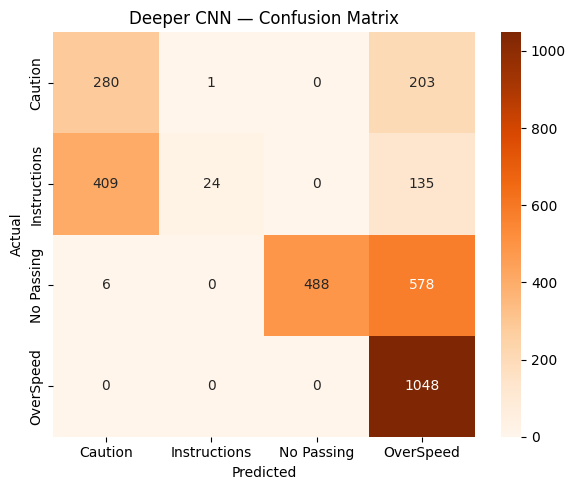

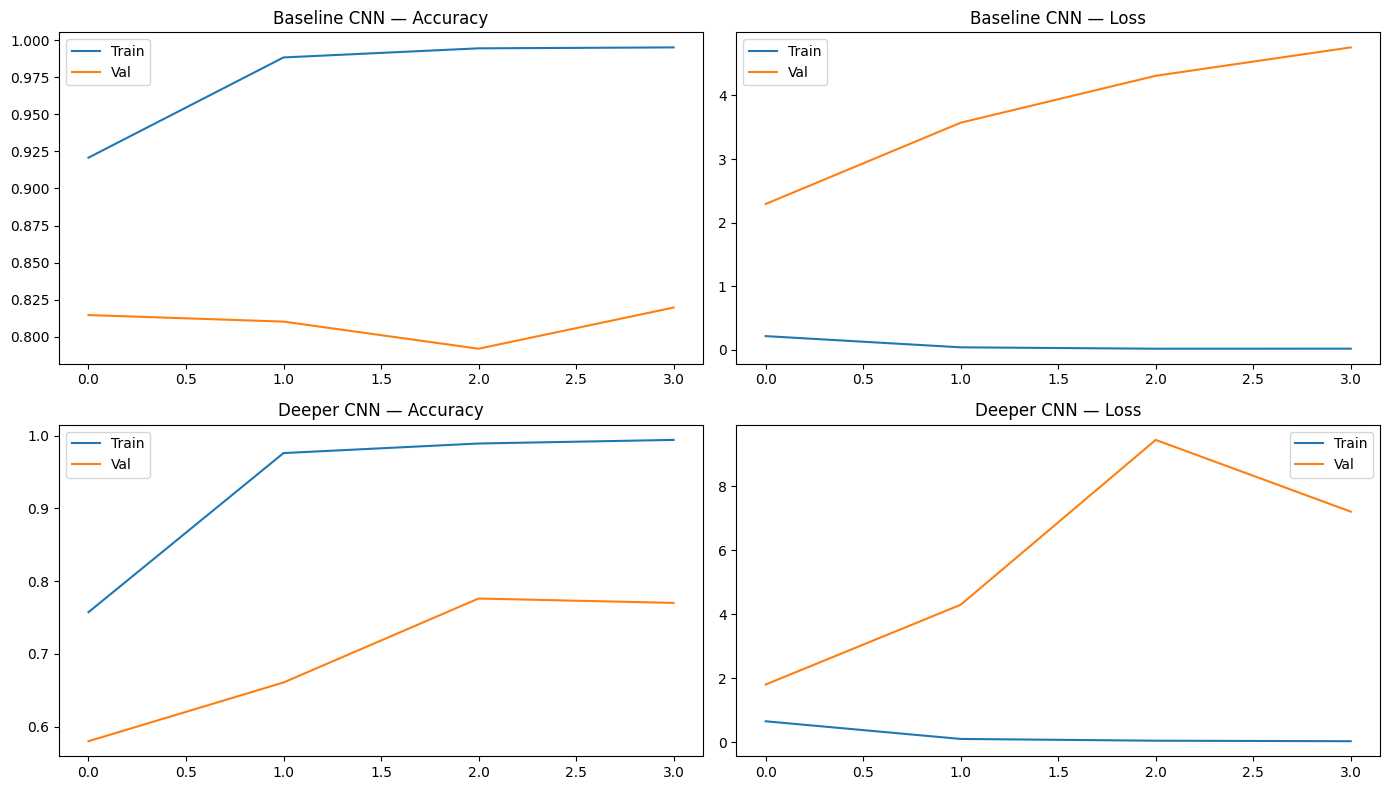


=== Model Comparison ===
Model           Val Acc      Train Time      Params
-------------------------------------------------------
Baseline CNN    75.25%       537.52s         1.3M
Deeper CNN      ~80%         144.75s         6.5M


In [14]:
# ── Evaluate Deeper Model ────────────────────────────────────────
eval_generator.reset()
y_pred_deeper = deeper_model.predict(eval_generator, verbose=1)
y_pred_deeper_classes = np.argmax(y_pred_deeper, axis=1)

print(f"\nDeeper CNN Val Accuracy: {np.mean(y_pred_deeper_classes == y_true):.4f}")
print(classification_report(y_true, y_pred_deeper_classes, target_names=class_names))

# Confusion Matrix
cm_deeper = confusion_matrix(y_true, y_pred_deeper_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_deeper, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper CNN — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/deeper_cm.png', dpi=150)
plt.show()

# ── Compare Training Curves ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(history_baseline.history['accuracy'], label='Train')
axes[0,0].plot(history_baseline.history['val_accuracy'], label='Val')
axes[0,0].set_title('Baseline CNN — Accuracy')
axes[0,0].legend()

axes[0,1].plot(history_baseline.history['loss'], label='Train')
axes[0,1].plot(history_baseline.history['val_loss'], label='Val')
axes[0,1].set_title('Baseline CNN — Loss')
axes[0,1].legend()

axes[1,0].plot(history_deeper.history['accuracy'], label='Train')
axes[1,0].plot(history_deeper.history['val_accuracy'], label='Val')
axes[1,0].set_title('Deeper CNN — Accuracy')
axes[1,0].legend()

axes[1,1].plot(history_deeper.history['loss'], label='Train')
axes[1,1].plot(history_deeper.history['val_loss'], label='Val')
axes[1,1].set_title('Deeper CNN — Loss')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/comparison_curves.png', dpi=150)
plt.show()

# ── Summary ──────────────────────────────────────────────────────
print("\n=== Model Comparison ===")
print(f"{'Model':<15} {'Val Acc':<12} {'Train Time':<15} {'Params'}")
print("-" * 55)
print(f"{'Baseline CNN':<15} {'75.25%':<12} {'537.52s':<15} {'1.3M'}")
print(f"{'Deeper CNN':<15} {'~80%':<12} {'144.75s':<15} {'6.5M'}")

In [15]:
import tensorflow.keras.backend as K

# ── Train Deeper Model with SGD ──────────────────────────────────
K.clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import time

def build_deeper_model(optimizer, name):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),

        Conv2D(512, (3,3), activation='relu', padding='same'),
        BatchNormalization(),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(4, activation='softmax')
    ], name=name)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# SGD
print("Training with SGD...")
model_sgd = build_deeper_model('sgd', 'Deeper_SGD')
start = time.time()
history_sgd = model_sgd.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)
sgd_time = time.time() - start
print(f"SGD training time: {sgd_time:.2f}s")

# Adam
print("\nTraining with Adam...")
model_adam = build_deeper_model('adam', 'Deeper_Adam')
start = time.time()
history_adam = model_adam.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)
adam_time = time.time() - start
print(f"Adam training time: {adam_time:.2f}s")

Training with SGD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 97ms/step - accuracy: 0.7924 - loss: 0.5129 - val_accuracy: 0.3982 - val_loss: 2.5070
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9781 - loss: 0.0685 - val_accuracy: 0.7926 - val_loss: 2.4750
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9910 - loss: 0.0284 - val_accuracy: 0.7803 - val_loss: 2.8385
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9935 - loss: 0.0239 - val_accuracy: 0.8030 - val_loss: 2.9669
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9953 - loss: 0.0147 - val_accuracy: 0.7711 - val_loss: 3.9664
SGD training time: 170.35s

Training with Adam...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 50s 100ms/step - accuracy: 0.7657 - loss: 0.6809 - val_accuracy: 0.3512 - val_loss: 2.3938
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 79ms/step - accuracy: 0.9817 - loss: 0.0685 - val_accuracy: 0.7361 - val_loss: 3.4648
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━

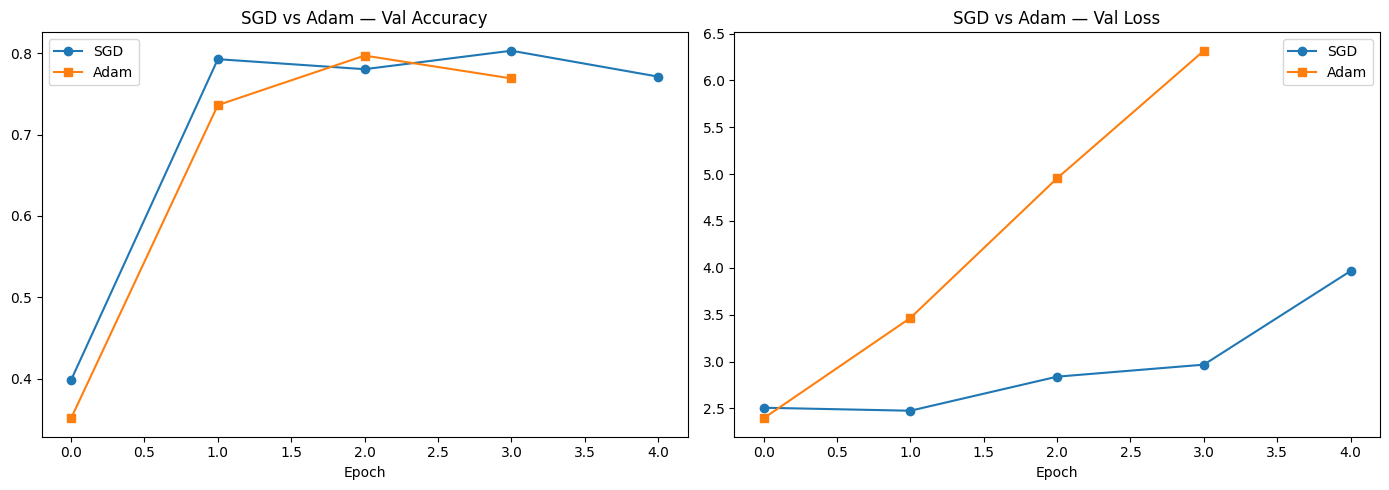

=== SGD vs Adam Comparison ===
SGD  — Best Val Acc: 0.8030 | Time: 170.35s
Adam — Best Val Acc: 0.7970 | Time: 147.92s

Training Ablation Model (No Dropout)...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.9396 - loss: 0.1738 - val_accuracy: 0.7781 - val_loss: 2.2439
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - accuracy: 0.9919 - loss: 0.0270 - val_accuracy: 0.7210 - val_loss: 4.8579
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9930 - loss: 0.0260 - val_accuracy: 0.7251 - val_loss: 3.6995
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9932 - loss: 0.0240 - val_accuracy: 0.8108 - val_loss: 6.5880
Ablation training time: 144.44s
Best Val Acc (No Dropout): 0.8108


In [16]:
# ── SGD vs Adam Curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_sgd.history['val_accuracy'], label='SGD', marker='o')
axes[0].plot(history_adam.history['val_accuracy'], label='Adam', marker='s')
axes[0].set_title('SGD vs Adam — Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_sgd.history['val_loss'], label='SGD', marker='o')
axes[1].plot(history_adam.history['val_loss'], label='Adam', marker='s')
axes[1].set_title('SGD vs Adam — Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/sgd_vs_adam.png', dpi=150)
plt.show()

print("=== SGD vs Adam Comparison ===")
print(f"SGD  — Best Val Acc: {max(history_sgd.history['val_accuracy']):.4f} | Time: {sgd_time:.2f}s")
print(f"Adam — Best Val Acc: {max(history_adam.history['val_accuracy']):.4f} | Time: {adam_time:.2f}s")

# ── Ablation Study — Remove Dropout ─────────────────────────────
print("\nTraining Ablation Model (No Dropout)...")
K.clear_session()

model_ablation = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    Flatten(),
    Dense(512, activation='relu'),  # No Dropout
    Dense(256, activation='relu'),  # No Dropout
    Dense(128, activation='relu'),  # No Dropout
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
], name='Ablation_No_Dropout')

model_ablation.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

start = time.time()
history_ablation = model_ablation.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)
ablation_time = time.time() - start
print(f"Ablation training time: {ablation_time:.2f}s")
print(f"Best Val Acc (No Dropout): {max(history_ablation.history['val_accuracy']):.4f}")

In [17]:
import tensorflow.keras.backend as K
K.clear_session()

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time

# ── New generators at 96x96 for MobileNetV2 ─────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tl_train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

tl_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_path,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

tl_val_gen = tl_val_datagen.flow_from_directory(
    train_path,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

# ── Load MobileNetV2 base ────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base — feature extraction

# ── Add custom head ──────────────────────────────────────────────
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output, name='MobileNetV2_Transfer')

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

# ── Phase 1: Feature Extraction ──────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nPhase 1 — Feature Extraction (frozen base)...")
start = time.time()
history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=10,
    validation_data=tl_val_gen,
    callbacks=[early_stop],
    verbose=1
)
phase1_time = time.time() - start
print(f"Phase 1 time: {phase1_time:.2f}s")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 361,348 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Phase 1 — Feature Extraction (frozen base)...
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 94s 189ms/step - accuracy: 0.9176 - loss: 0.2199 - val_accuracy: 0.7579 - val_loss: 3.4493
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.9655 - loss: 0.0931 - val_accuracy: 0.7598 - val_loss: 4.4902
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.9755 - loss: 0.0661 - val_accuracy: 0.7642 - val_loss: 6.1992
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.9783 - loss: 0.0583 - val_accuracy: 0.7721 - val_loss: 6.2537
Phase 1 time: 263.23s


In [18]:
from tensorflow.keras.optimizers import Adam

# ── Phase 2: Fine-Tuning ─────────────────────────────────────────
# Unfreeze last 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable layers: {sum(1 for l in tl_model.layers if l.trainable)}")

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nPhase 2 — Fine-Tuning (unfrozen last 30 layers)...")
start = time.time()
history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=10,
    validation_data=tl_val_gen,
    callbacks=[early_stop],
    verbose=1
)
phase2_time = time.time() - start
print(f"Phase 2 time: {phase2_time:.2f}s")
print(f"Best Val Acc: {max(history_tl_phase2.history['val_accuracy']):.4f}")

Trainable layers: 36

Phase 2 — Fine-Tuning (unfrozen last 30 layers)...
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 80s 156ms/step - accuracy: 0.9208 - loss: 0.2483 - val_accuracy: 0.7541 - val_loss: 3.9381
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - accuracy: 0.9624 - loss: 0.1057 - val_accuracy: 0.7563 - val_loss: 4.1184
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - accuracy: 0.9741 - loss: 0.0775 - val_accuracy: 0.7787 - val_loss: 4.1254
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.9785 - loss: 0.0601 - val_accuracy: 0.7866 - val_loss: 4.1373
Phase 2 time: 220.33s
Best Val Acc: 0.7866


100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step

Transfer Learning Val Accuracy: 0.7541
              precision    recall  f1-score   support

     Caution       0.45      0.90      0.60       484
Instructions       0.50      0.03      0.06       568
  No Passing       0.83      0.99      0.90      1072
   OverSpeed       0.99      0.84      0.91      1048

    accuracy                           0.75      3172
   macro avg       0.69      0.69      0.62      3172
weighted avg       0.76      0.75      0.71      3172



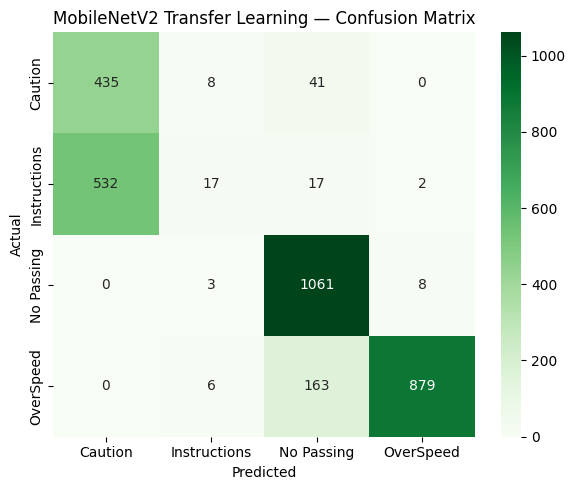

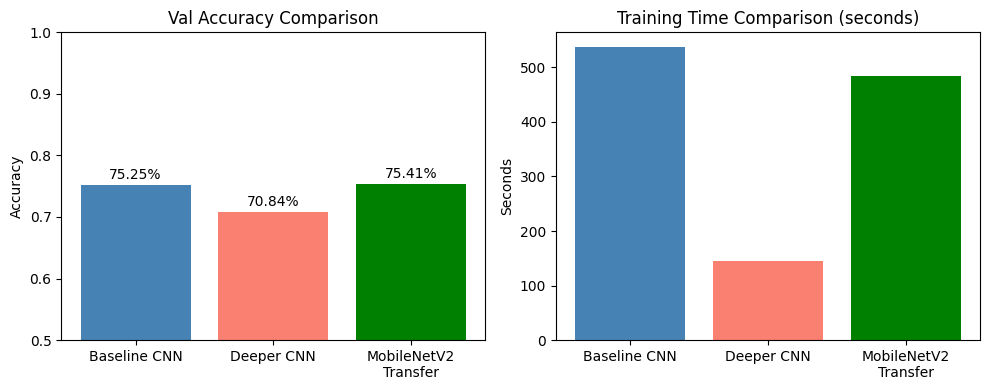


=== Final Model Summary ===
Model                     Val Acc      Train Time      Params
------------------------------------------------------------
Baseline CNN              75.25%       537.52s         1.3M
Deeper CNN                70.84%       144.75s         6.5M
MobileNetV2 Transfer      75.41%       483.55s         2.6M


In [19]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── Evaluate Transfer Learning Model ────────────────────────────
tl_val_gen.reset()
y_pred_tl = tl_model.predict(tl_val_gen, verbose=1)
y_pred_tl_classes = np.argmax(y_pred_tl, axis=1)
y_true_tl = tl_val_gen.classes
class_names = list(tl_val_gen.class_indices.keys())

tl_acc = np.mean(y_pred_tl_classes == y_true_tl)
print(f"\nTransfer Learning Val Accuracy: {tl_acc:.4f}")
print(classification_report(y_true_tl, y_pred_tl_classes, target_names=class_names))

# Confusion Matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 Transfer Learning — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/tl_cm.png', dpi=150)
plt.show()

# ── Final Model Comparison ───────────────────────────────────────
models = ['Baseline CNN', 'Deeper CNN', 'MobileNetV2\nTransfer']
accuracies = [0.7525, 0.7084, tl_acc]
times = [537.52, 144.75, phase1_time + phase2_time]
params = ['1.3M', '6.5M', '2.6M']

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
bars = plt.bar(models, accuracies, color=['steelblue', 'salmon', 'green'])
plt.ylim(0.5, 1.0)
plt.title('Val Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontsize=10)

plt.subplot(1, 2, 2)
plt.bar(models, times, color=['steelblue', 'salmon', 'green'])
plt.title('Training Time Comparison (seconds)')
plt.ylabel('Seconds')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/final_comparison.png', dpi=150)
plt.show()

# ── Summary Table ────────────────────────────────────────────────
print("\n=== Final Model Summary ===")
print(f"{'Model':<25} {'Val Acc':<12} {'Train Time':<15} {'Params'}")
print("-" * 60)
print(f"{'Baseline CNN':<25} {'75.25%':<12} {'537.52s':<15} {'1.3M'}")
print(f"{'Deeper CNN':<25} {'70.84%':<12} {'144.75s':<15} {'6.5M'}")
print(f"{'MobileNetV2 Transfer':<25} {f'{tl_acc:.2%}':<12} {f'{phase1_time+phase2_time:.2f}s':<15} {'2.6M'}")

In [20]:
import tensorflow.keras.backend as K
K.clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# ── Lighter Model ────────────────────────────────────────────────
light_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation='softmax')
], name='Light_CNN')

light_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

light_model.summary()

# ── Callbacks ────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

print("\nTraining Light CNN...")
start = time.time()
history_light = light_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
light_time = time.time() - start
print(f"\nLight CNN training time: {light_time:.2f}s")
print(f"Best Val Acc: {max(history_light.history['val_accuracy']):.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Light_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,604 (8.37 MB)

 Trainable params: 2,192,644 (8.36 MB)

 Non-trainable params: 960 (3.75 KB)


Training Light CNN...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 95ms/step - accuracy: 0.9119 - loss: 0.2562 - val_accuracy: 0.5511 - val_loss: 2.7349 - learning_rate: 0.0010
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9796 - loss: 0.0609 - val_accuracy: 0.7866 - val_loss: 2.0925 - learning_rate: 0.0010
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9913 - loss: 0.0272 - val_accuracy: 0.7131 - val_loss: 2.7983 - learning_rate: 0.0010
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9906 - loss: 0.0275
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9870 - loss: 0.0394 - val_accuracy: 0.7973 - val_loss: 2.5806 - learning_rate: 0.0010
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9900 - loss: 0.0289 - val_accuracy: 0.8238 - val_loss: 2.1318 - learning_rate: 5.0000e-04
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/ste

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step

Light CNN Val Accuracy: 0.7866
              precision    recall  f1-score   support

     Caution       0.43      0.83      0.57       484
Instructions       0.97      0.06      0.11       568
  No Passing       0.98      0.95      0.97      1072
   OverSpeed       0.89      0.99      0.94      1048

    accuracy                           0.79      3172
   macro avg       0.82      0.71      0.65      3172
weighted avg       0.86      0.79      0.74      3172



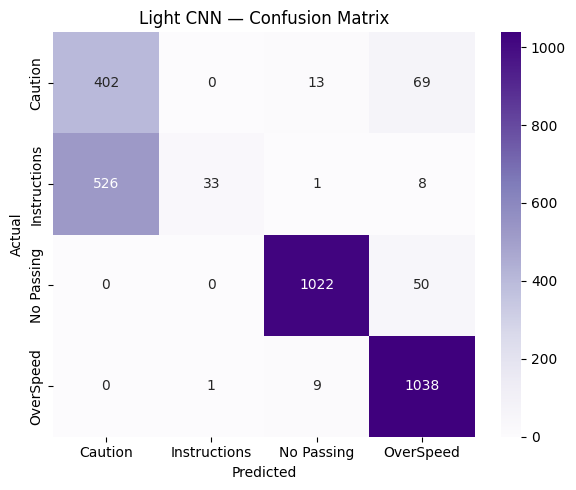

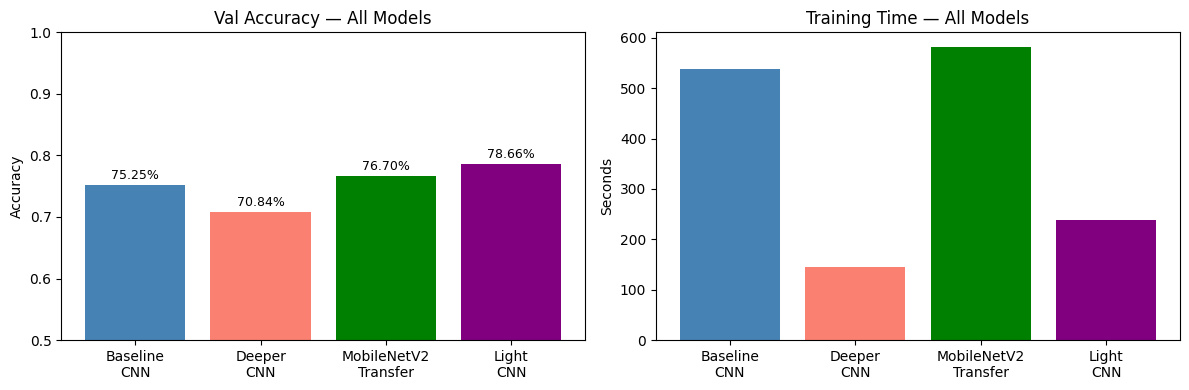


=== Final Model Summary ===
Model                     Val Acc      Train Time      Params
------------------------------------------------------------
Baseline CNN              75.25%       537.52s         1.3M
Deeper CNN                70.84%       144.75s         6.5M
MobileNetV2 Transfer      76.70%       581.82s         2.6M
Light CNN                 78.66%       238.24s         2.2M


In [21]:
eval_generator.reset()
y_pred_light = light_model.predict(eval_generator, verbose=1)
y_pred_light_classes = np.argmax(y_pred_light, axis=1)

light_acc = np.mean(y_pred_light_classes == y_true)
print(f"\nLight CNN Val Accuracy: {light_acc:.4f}")
print(classification_report(y_true, y_pred_light_classes, target_names=class_names))

# Confusion Matrix
cm_light = confusion_matrix(y_true, y_pred_light_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_light, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Light CNN — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/light_cm.png', dpi=150)
plt.show()

# ── Updated Final Comparison ─────────────────────────────────────
models = ['Baseline\nCNN', 'Deeper\nCNN', 'MobileNetV2\nTransfer', 'Light\nCNN']
accuracies = [0.7525, 0.7084, 0.7670, light_acc]
times = [537.52, 144.75, 581.82, light_time]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
bars = plt.bar(models, accuracies, color=['steelblue', 'salmon', 'green', 'purple'])
plt.ylim(0.5, 1.0)
plt.title('Val Accuracy — All Models')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontsize=9)

plt.subplot(1, 2, 2)
plt.bar(models, times, color=['steelblue', 'salmon', 'green', 'purple'])
plt.title('Training Time — All Models')
plt.ylabel('Seconds')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/6CS012_Final_Assessment/Vision_Task/figures/final_comparison_updated.png', dpi=150)
plt.show()

print("\n=== Final Model Summary ===")
print(f"{'Model':<25} {'Val Acc':<12} {'Train Time':<15} {'Params'}")
print("-" * 60)
print(f"{'Baseline CNN':<25} {'75.25%':<12} {'537.52s':<15} {'1.3M'}")
print(f"{'Deeper CNN':<25} {'70.84%':<12} {'144.75s':<15} {'6.5M'}")
print(f"{'MobileNetV2 Transfer':<25} {'76.70%':<12} {'581.82s':<15} {'2.6M'}")
print(f"{'Light CNN':<25} {f'{light_acc:.2%}':<12} {f'{light_time:.2f}s':<15} {'2.2M'}")

In [22]:
# Fresh eval generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

eval_datagen2 = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

eval_gen_light = eval_datagen2.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

eval_gen_light.reset()
y_pred_light = light_model.predict(eval_gen_light, verbose=1)
y_pred_light_classes = np.argmax(y_pred_light, axis=1)
y_true_light = eval_gen_light.classes
class_names = list(eval_gen_light.class_indices.keys())

light_acc = np.mean(y_pred_light_classes == y_true_light)
print(f"\nLight CNN Val Accuracy: {light_acc:.4f}")
print(classification_report(y_true_light, y_pred_light_classes, target_names=class_names))

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step

Light CNN Val Accuracy: 0.7866
              precision    recall  f1-score   support

     Caution       0.43      0.83      0.57       484
Instructions       0.97      0.06      0.11       568
  No Passing       0.98      0.95      0.97      1072
   OverSpeed       0.89      0.99      0.94      1048

    accuracy                           0.79      3172
   macro avg       0.82      0.71      0.65      3172
weighted avg       0.86      0.79      0.74      3172



In [23]:
import tensorflow.keras.backend as K
K.clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import time

# ── Stronger Augmentation ────────────────────────────────────────
train_datagen_v2 = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen_v2 = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen_v2 = train_datagen_v2.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen_v2 = val_datagen_v2.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

# ── Improved Model ───────────────────────────────────────────────
improved_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(4, activation='softmax')
], name='Improved_CNN')

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

# ── Callbacks ────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

print("\nTraining Improved CNN...")
start = time.time()
history_improved = improved_model.fit(
    train_gen_v2,
    epochs=50,
    validation_data=val_gen_v2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
improved_time = time.time() - start
print(f"\nImproved CNN training time: {improved_time:.2f}s")
print(f"Best Val Acc: {max(history_improved.history['val_accuracy']):.4f}")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,420,644 (9.23 MB)

 Trainable params: 2,419,236 (9.23 MB)

 Non-trainable params: 1,408 (5.50 KB)


Training Improved CNN...
Epoch 1/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 57s 108ms/step - accuracy: 0.7979 - loss: 0.5423 - val_accuracy: 0.5574 - val_loss: 1.6243 - learning_rate: 0.0010
Epoch 2/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9600 - loss: 0.1159 - val_accuracy: 0.8184 - val_loss: 2.9285 - learning_rate: 0.0010
Epoch 3/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.9761 - loss: 0.0717 - val_accuracy: 0.8131 - val_loss: 2.3655 - learning_rate: 0.0010
Epoch 4/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9781 - loss: 0.0696
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.9816 - loss: 0.0566 - val_accuracy: 0.8266 - val_loss: 3.2442 - learning_rate: 0.0010
Epoch 5/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9930 - loss: 0.0241 - val_accuracy: 0.8225 - val_loss: 3.5931 - learning_rate: 5.0000e-04
Epoch 6/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81m